# 5-A2. 전국 수요 — 지평별 직접모델 (Direct-H: D+1/D+2/D+3/D+7/D+12)

> 5-A(풀드: 한 모델이 1~168h 전부 학습)와 달리, **날짜마다 모델을 따로** 둔다(Direct-H).
> 사용자 확정(§0.6): 출력=**D+n 하루(24시간) 블록**, 세트=**D+1·D+2·D+3·D+7·D+12** 5개,
> 풀드 5-A는 유지하고 **동일 test에서 비교**.
>
> ## 블록 ↔ 지평(origin=23:00 기준 lead h)
> D+1=h1..24 · D+2=h25..48 · D+3=h49..72 · D+7=h145..168 · D+12=h265..288.
>
> ## 피처 (블록마다 동일 템플릿, 주간앵커만 교체)
> - **lag_week** = 같은 요일·시각의 가장 가까운 과거. h≤168이면 target−168, **D+12는 target−336**(2주 전).
> - rec24, rec168 (원점까지 최근 레벨) · 기상3(기온/일사/풍속 5지점평균) · 달력(hour/dow/month sin·cos) · day_type.
> - 누수 없음(모든 lag/rec는 ≤origin, 달력은 결정값, 기상은 예보로 대체 가능).
> - 평가 정직성 2겹: **완전기상(실측 투입)↔기후값(월,시 평균)**. 운영은 그 사이.

In [1]:
import os, sqlite3, json, warnings
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt, matplotlib as mpl
warnings.filterwarnings('ignore')
mpl.rcParams['font.family']='Malgun Gothic'; mpl.rcParams['axes.unicode_minus']=False; mpl.rcParams['figure.dpi']=110
HERE=os.getcwd()
FIG=os.path.join(HERE,'fig'); TAB=os.path.join(HERE,'tab'); MODELS=os.path.join(HERE,'models')
for p in (FIG,TAB,MODELS): os.makedirs(p,exist_ok=True)
DB=os.path.normpath(os.path.join(HERE,'..','..','1. data_fetcher_and_db','data','input_data_land.db'))
ST=['daegwallyeong','wonju','seosan','pohang','yeonggwang']; WX=['temp_c','solar_rad','wind_spd']
DTCATS=['holiday','weekday','weekend']
pull=['timestamp','real_demand_land','land_est_demand_da','day_type']+[f'{w}_{s}' for s in ST for w in WX]
con=sqlite3.connect(DB); raw=pd.read_sql(f"SELECT {', '.join(pull)} FROM historical",con,parse_dates=['timestamp']);con.close()
raw=raw.sort_values('timestamp')
for w in WX: raw[w]=raw[[f'{w}_{s}' for s in ST]].mean(axis=1)
idx=pd.date_range(raw.timestamp.min(),raw.timestamp.max(),freq='h')
d=raw.set_index('timestamp')[['real_demand_land','land_est_demand_da','day_type']+WX].reindex(idx)
d.loc[d.real_demand_land==0,'real_demand_land']=np.nan
d['real_demand_land']=d['real_demand_land'].interpolate('time')
for w in WX: d[w]=d[w].interpolate('time')
d['day_type']=d['day_type'].ffill().bfill()
print(d.shape, idx.min(),'~',idx.max())

(56352, 6) 2020-01-01 00:00:00 ~ 2026-06-05 23:00:00


## 1. 배열 준비 + 블록 샘플 빌더

In [2]:
dem=d.real_demand_land.values.astype(float); base=d.land_est_demand_da.values.astype(float)
temp=d.temp_c.values; solar=d.solar_rad.values; wind=d.wind_spd.values
hour=d.index.hour.values; dow=d.index.dayofweek.values; month=d.index.month.values; year=d.index.year.values
dtype=d.day_type.values.astype(object)
rec24=pd.Series(dem).rolling(24,min_periods=24).mean().values
rec168=pd.Series(dem).rolling(168,min_periods=168).mean().values
N=len(d)
BLOCKS={1:(1,24),2:(25,48),3:(49,72),7:(145,168),12:(265,288)}
MAXLEAD=288; MAXLAG=336

def make_block(n):
    h0,h1=BLOCKS[n]; H=np.arange(h0,h1+1)
    lagw=168 if n<=7 else 336
    # origin: hour==23, 충분한 과거(MAXLAG)·미래(MAXLEAD)
    P=np.where((hour==23)&(np.arange(N)>=MAXLAG)&(np.arange(N)<=N-1-MAXLEAD))[0]
    tgt=(P[:,None]+H[None,:]).ravel(); hh=np.broadcast_to(H,(len(P),len(H))).ravel()
    df=pd.DataFrame({
        'y':dem[tgt],'h':hh.astype(np.int16),
        'lag_week':dem[tgt-lagw],
        'lag168':dem[tgt-168] if n<=7 else np.nan,           # 풀드 비교용(D+12는 미가용)
        'lag24':np.where(hh<=24,dem[tgt-24],np.nan),          # 풀드 비교용
        'rec24':np.repeat(rec24[P],len(H)),'rec168':np.repeat(rec168[P],len(H)),
        'temp_c':temp[tgt],'solar_rad':solar[tgt],'wind_spd':wind[tgt],
        'hour':hour[tgt],'dow':dow[tgt],'month':month[tgt],
        'day_type':dtype[tgt],'lag_dt':dtype[tgt-lagw],          # ★ lag_week 시점의 day_type(공휴일 보정)
        'base':base[tgt],'tyear':year[tgt],'tts':d.index.values[tgt]})
    for a,p in [('hour',24),('dow',7),('month',12)]:
        df[a+'_sin']=np.sin(2*np.pi*df[a]/p); df[a+'_cos']=np.cos(2*np.pi*df[a]/p)
    df=df[df.y.notna()&df.lag_week.notna()].reset_index(drop=True)
    df['day_type']=pd.Categorical(df['day_type'],categories=DTCATS)
    df['lag_dt']=pd.Categorical(df['lag_dt'],categories=DTCATS)
    df['mismatch']=df.day_type.astype(str)!=df.lag_dt.astype(str)
    return df
print({n:make_block(n).shape for n in BLOCKS})

{1: (55728, 25), 2: (55728, 25), 3: (55728, 25), 7: (55728, 25), 12: (55728, 25)}


## 2. 학습 + 공휴일 피처 A/B (lag_dt 추가 전후)

타깃이 공휴일인데 lag_week(7일 전)는 평일이면 lag_week가 높은 평일값을 주입한다. 모델은 타깃 day_type만
알아 평균적 보정만 했다(공휴일 MAPE가 전체의 2배). **lag_dt**(lag_week 시점의 day_type)를 주면
"이 lag가 평일이었는지"를 알고 정확히 보정할 수 있다. 블록마다 **base(lag_dt 없음) vs +holiday(lag_dt)**
두 버전을 학습해 효과를 측정하고, **+holiday를 최종 모델로 저장**한다.

In [3]:
CYC=['hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos']
FEAT_BASE=['lag_week','rec24','rec168']+WX+CYC+['day_type']
FEAT_HOL =FEAT_BASE+['lag_dt']                    # ★ 공휴일 보정 피처 추가
PARAMS=dict(objective='regression_l1',metric='mae',learning_rate=0.03,num_leaves=127,
            min_data_in_leaf=80,feature_fraction=0.85,bagging_fraction=0.8,bagging_freq=5,
            lambda_l2=0.2,verbosity=-1,random_state=42)
def mape(a,p):
    a=np.asarray(a,float);p=np.asarray(p,float);m=(a>0)&np.isfinite(a)&np.isfinite(p)
    return float(np.mean(np.abs(a[m]-p[m])/a[m])*100)
def clim_table(tr): return {w:tr.groupby([tr.hour,tr.month])[w].mean() for w in WX}
def fit(tr,va,feats,cat):
    dtr=lgb.Dataset(tr[feats],tr.y,categorical_feature=cat)
    dva=lgb.Dataset(va[feats],va.y,categorical_feature=cat,reference=dtr)
    return lgb.train(PARAMS,dtr,num_boost_round=3000,valid_sets=[dva],valid_names=['val'],
                     callbacks=[lgb.early_stopping(120),lgb.log_evaluation(0)])

dh_models={}; rows=[]; test_store={}
for n in BLOCKS:
    s=make_block(n)
    tr=s[s.tyear<=2024]; va=s[s.tyear==2025]; te=s[s.tyear==2026].copy()
    m0=fit(tr,va,FEAT_BASE,['day_type'])                 # base = 최종 채택
    m1=fit(tr,va,FEAT_HOL,['day_type','lag_dt'])         # +lag_dt = A/B 비교용(미채택)
    dh_models[n]=m0
    te['pred']    =m0.predict(te[FEAT_BASE],num_iteration=m0.best_iteration)   # 최종(base)
    te['pred_hol']=m1.predict(te[FEAT_HOL], num_iteration=m1.best_iteration)   # A/B(+lag_dt)
    cl=clim_table(tr); te_c=te.copy()
    for w in WX: te_c[w]=[cl[w].get((h_,mo),np.nan) for h_,mo in zip(te_c.hour,te_c.month)]
    te['pred_clim']=m0.predict(te_c[FEAT_BASE],num_iteration=m0.best_iteration)
    test_store[n]=te
    hol=te[te.day_type.astype(str)=='holiday']; mis=te[te.mismatch]   # 불일치=문제 케이스(표본 더 큼)
    rows.append(dict(model=f'D+{n}', perfect=mape(te.y,te.pred), climatology=mape(te.y,te.pred_clim),
                     all_hol=mape(te.y,te.pred_hol),
                     hol_base=mape(hol.y,hol.pred), hol_hol=mape(hol.y,hol.pred_hol), n_hol=len(hol),
                     mis_base=mape(mis.y,mis.pred), mis_hol=mape(mis.y,mis.pred_hol), n_mis=len(mis),
                     naive_week=mape(te.y,te.lag_week), kpx=mape(te.y,te.base), n_test=len(te)))
    r=rows[-1]
    print(f'D+{n:>2}  base={r["perfect"]:.2f}% (+lag_dt {r["all_hol"]:.2f}%)  '
          f'불일치(n={r["n_mis"]}) {r["mis_base"]:.2f}→{r["mis_hol"]:.2f}%  '
          f'공휴일(n={r["n_hol"]}) {r["hol_base"]:.2f}→{r["hol_hol"]:.2f}%  KPX={r["kpx"]:.2f}%')
dh=pd.DataFrame(rows)

Training until validation scores don't improve for 120 rounds


Did not meet early stopping. Best iteration is:
[2997]	val's l1: 1608.55


Training until validation scores don't improve for 120 rounds


Did not meet early stopping. Best iteration is:
[2998]	val's l1: 1562.96


D+ 1  base=3.48% (+lag_dt 3.35%)  불일치(n=360) 5.85→5.44%  공휴일(n=216) 6.76→6.59%  KPX=5.30%
Training until validation scores don't improve for 120 rounds


...

D+ 7  base=4.26% (+lag_dt 4.22%)  불일치(n=384) 6.62→7.17%  공휴일(n=216) 8.43→8.86%  KPX=5.44%
Training until validation scores don't improve for 120 rounds


Early stopping, best iteration is:
[987]	val's l1: 2264.74


Training until validation scores don't improve for 120 rounds


Early stopping, best iteration is:
[1136]	val's l1: 2228.73


D+12  base=4.59% (+lag_dt 4.44%)  불일치(n=384) 6.69→6.43%  공휴일(n=240) 8.16→8.19%  KPX=5.48%


## 3. 풀드 5-A 대비 (동일 test 행에서 비교)

풀드 5-A는 1~168h 학습이라 D+1~D+7만 비교 가능(D+12는 lag168 미가용 → Direct-H 단독).

model  DirectH_perfect  DirectH_clim  Pooled_perfect  KPX
  D+1             3.48          4.35            3.36 5.30
  D+2             3.76          4.68            3.74 5.37
  D+3             3.94          4.85            3.88 5.42
  D+7             4.26          5.29            4.19 5.44
 D+12             4.59          5.56             NaN 5.48


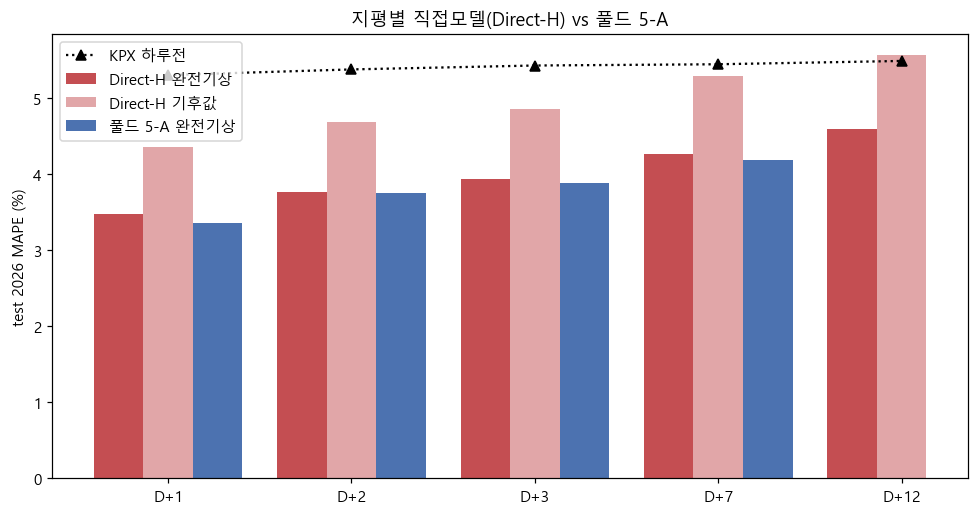

In [4]:
POOL=os.path.join(MODELS,'lgbm_land_demand_direct.txt')
FEAT_POOL=['h','lag168','lag24','rec24','rec168']+WX+CYC+['day_type']
pooled=lgb.Booster(model_file=POOL) if os.path.exists(POOL) else None
comp=[]
for n in BLOCKS:
    te=test_store[n]; r={'model':f'D+{n}','DirectH_perfect':mape(te.y,te.pred),'DirectH_clim':mape(te.y,te.pred_clim)}
    if pooled is not None and n<=7:
        pe=te.copy(); pe['day_type']=pd.Categorical(pe['day_type'],categories=DTCATS)
        r['Pooled_perfect']=mape(te.y, pooled.predict(pe[FEAT_POOL]))
    else:
        r['Pooled_perfect']=np.nan
    r['KPX']=mape(te.y,te.base); comp.append(r)
comp=pd.DataFrame(comp); comp.to_csv(os.path.join(TAB,'5-A2_compare.csv'),index=False)
print(comp.round(2).to_string(index=False))

fig,ax=plt.subplots(figsize=(9,4.8))
x=np.arange(len(comp)); w=0.27
ax.bar(x-w,comp.DirectH_perfect,w,label='Direct-H 완전기상',color='#C44E52')
ax.bar(x,   comp.DirectH_clim,  w,label='Direct-H 기후값',color='#C44E52',alpha=.5)
ax.bar(x+w, comp.Pooled_perfect,w,label='풀드 5-A 완전기상',color='#4C72B0')
ax.plot(x, comp.KPX, 'k^:', label='KPX 하루전')
ax.set_xticks(x); ax.set_xticklabels(comp.model); ax.set_ylabel('test 2026 MAPE (%)')
ax.set_title('지평별 직접모델(Direct-H) vs 풀드 5-A'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(FIG,'5-A2_compare.png'),bbox_inches='tight'); plt.show()

## 4. 피처 중요도(블록별) + 저장 + 보고서

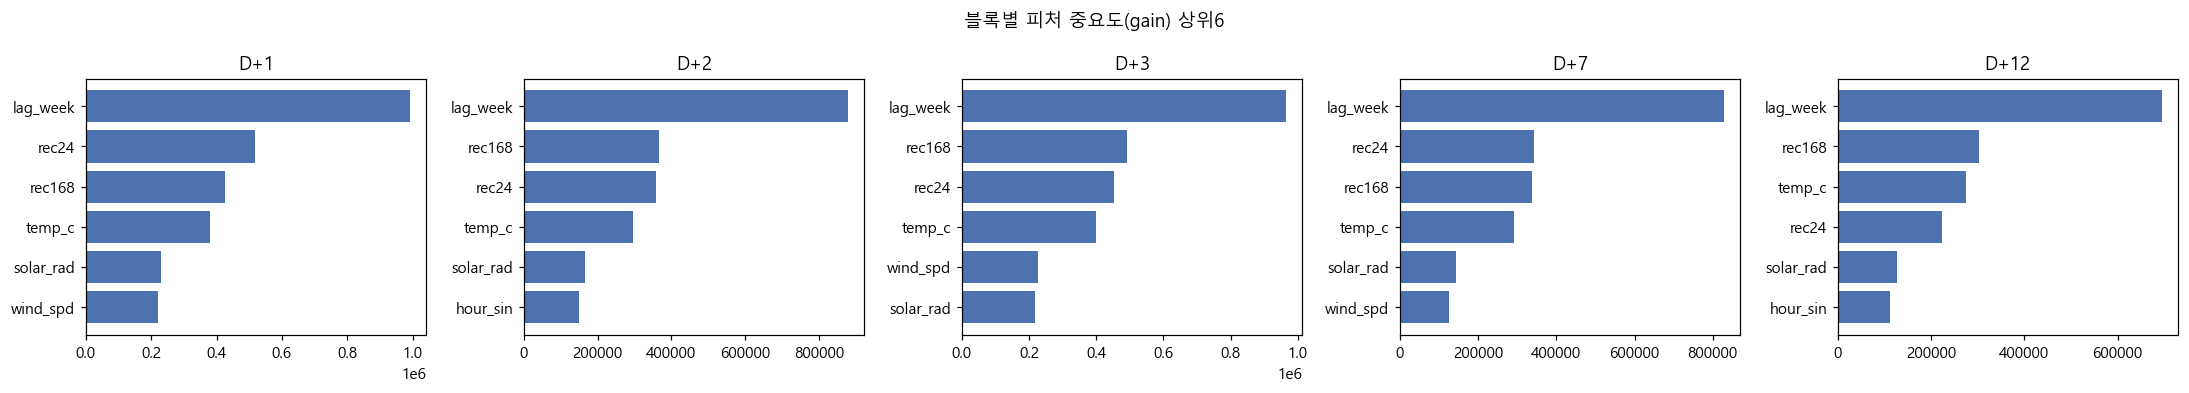

# 5-A2 보고서 — 전국 수요 지평별 직접모델(Direct-H)

## 구조 (사용자 확정)
- D+n 하루(24h) 블록 직접모델 **5개**: D+1·D+2·D+3·D+7·D+12. 풀드 5-A는 유지(비교용).
- 피처(동일 템플릿): lag_week + rec24 + rec168 + 기상3 + 달력 + day_type. **주간앵커 lag_week = target−168(D+1~7) / target−336(D+12, lag336)**.
- 학습창 train≤2024/val2025/test2026. 평가 완전기상(상한)↔기후값(하한).

## 결과 (test 2026, MAPE %)
| 모델 | Direct-H 완전기상 | Direct-H 기후값 | 풀드 5-A 완전기상 | KPX 하루전 | naive(주간lag) |
|---|---|---|---|---|---|
| D+1  | 3.48 | 4.35 | 3.36 | 5.30 | 7.03 |
| D+2  | 3.76 | 4.68 | 3.74 | 5.37 | 7.07 |
| D+3  | 3.94 | 4.85 | 3.88 | 5.42 | 7.14 |
| D+7  | 4.26 | 5.29 | 4.19 | 5.44 | 7.13 |
| D+12 | 4.59 | 5.56 | — (풀드 미지원) | 5.48 | 7.84 |

- D+12는 lag336(2주 전)을 주간앵커로 사용(lag168이 미래라 불가). 멀수록·앵커 멀수록 점진적 하락.
- 풀드 vs Direct-H: 위 표/그림(5-A2_compare.png)에서 동일 test 직접 비교(풀드가 ~0.1~0.3%p 근소 우위 = 데이터 공유 효과).

## 공휴일 보정 실험 — lag_dt 테스트 후 미채택 (사용자 지적)
lag_week는 7일 전(같은 요일)이라 타깃이 공휴일·7일 전이 평일이면 평일값을 주입 → 공휴일 MAPE가 전체의 2배.
**lag_dt(lag_week 시점 day_type)** 를 추가하면 모델이 그 차이를 알 수 있어 A/B로

In [5]:
fig,axes=plt.subplots(1,len(BLOCKS),figsize=(20,3.6),sharex=False)
for ax,n in zip(axes,BLOCKS):
    m=dh_models[n]
    imp=pd.DataFrame({'f':m.feature_name(),'g':m.feature_importance('gain')}).sort_values('g').tail(6)
    ax.barh(imp.f,imp.g,color='#4C72B0'); ax.set_title(f'D+{n}')
plt.suptitle('블록별 피처 중요도(gain) 상위6'); plt.tight_layout()
plt.savefig(os.path.join(FIG,'5-A2_importance.png'),bbox_inches='tight'); plt.show()

meta={}
for n,m in dh_models.items():
    fn=os.path.join(MODELS,f'lgbm_land_demand_D{n}.txt'); m.save_model(fn,num_iteration=m.best_iteration)
    meta[f'D+{n}']=dict(file=os.path.basename(fn),block_hours=list(BLOCKS[n]),
                        lag_week=(168 if n<=7 else 336),best_iteration=int(m.best_iteration))
meta['_common']=dict(features=FEAT_BASE,categorical=['day_type'],target='real_demand_land',origin_hour=23,
                     weather=WX+['5-station mean'],train='target<=2024',val='2025',test='2026',params=PARAMS,
                     note='lag_dt(=day_type of lag_week) A/B 테스트했으나 효과 미미·비일관으로 미채택; 최종=base. weather=actual(perfect upper)/climatology(lower)')
json.dump(meta,open(os.path.join(MODELS,'model_meta_perhorizon.json'),'w',encoding='utf-8'),ensure_ascii=False,indent=2)

def row(n,c): return dh[dh.model==f'D+{n}'][c].iloc[0]
def cmp(n,c):
    v=comp[comp.model==f'D+{n}'][c].iloc[0]; return f'{v:.2f}' if pd.notna(v) else '—'
rep=f'''# 5-A2 보고서 — 전국 수요 지평별 직접모델(Direct-H)

## 구조 (사용자 확정)
- D+n 하루(24h) 블록 직접모델 **5개**: D+1·D+2·D+3·D+7·D+12. 풀드 5-A는 유지(비교용).
- 피처(동일 템플릿): lag_week + rec24 + rec168 + 기상3 + 달력 + day_type. **주간앵커 lag_week = target−168(D+1~7) / target−336(D+12, lag336)**.
- 학습창 train≤2024/val2025/test2026. 평가 완전기상(상한)↔기후값(하한).

## 결과 (test 2026, MAPE %)
| 모델 | Direct-H 완전기상 | Direct-H 기후값 | 풀드 5-A 완전기상 | KPX 하루전 | naive(주간lag) |
|---|---|---|---|---|---|
| D+1  | {cmp(1,'DirectH_perfect')} | {cmp(1,'DirectH_clim')} | {cmp(1,'Pooled_perfect')} | {row(1,'kpx'):.2f} | {row(1,'naive_week'):.2f} |
| D+2  | {cmp(2,'DirectH_perfect')} | {cmp(2,'DirectH_clim')} | {cmp(2,'Pooled_perfect')} | {row(2,'kpx'):.2f} | {row(2,'naive_week'):.2f} |
| D+3  | {cmp(3,'DirectH_perfect')} | {cmp(3,'DirectH_clim')} | {cmp(3,'Pooled_perfect')} | {row(3,'kpx'):.2f} | {row(3,'naive_week'):.2f} |
| D+7  | {cmp(7,'DirectH_perfect')} | {cmp(7,'DirectH_clim')} | {cmp(7,'Pooled_perfect')} | {row(7,'kpx'):.2f} | {row(7,'naive_week'):.2f} |
| D+12 | {cmp(12,'DirectH_perfect')} | {cmp(12,'DirectH_clim')} | — (풀드 미지원) | {row(12,'kpx'):.2f} | {row(12,'naive_week'):.2f} |

- D+12는 lag336(2주 전)을 주간앵커로 사용(lag168이 미래라 불가). 멀수록·앵커 멀수록 점진적 하락.
- 풀드 vs Direct-H: 위 표/그림(5-A2_compare.png)에서 동일 test 직접 비교(풀드가 ~0.1~0.3%p 근소 우위 = 데이터 공유 효과).

## 공휴일 보정 실험 — lag_dt 테스트 후 미채택 (사용자 지적)
lag_week는 7일 전(같은 요일)이라 타깃이 공휴일·7일 전이 평일이면 평일값을 주입 → 공휴일 MAPE가 전체의 2배.
**lag_dt(lag_week 시점 day_type)** 를 추가하면 모델이 그 차이를 알 수 있어 A/B로 검증했다.

base → +lag_dt MAPE (%):

| 모델 | 전체 | 불일치 케이스(n) | 공휴일 타깃(n) |
|---|---|---|---|
| D+1  | {row(1,'perfect'):.2f}→{row(1,'all_hol'):.2f} | {row(1,'mis_base'):.2f}→{row(1,'mis_hol'):.2f} (n={int(row(1,'n_mis'))}) | {row(1,'hol_base'):.2f}→{row(1,'hol_hol'):.2f} (n={int(row(1,'n_hol'))}) |
| D+2  | {row(2,'perfect'):.2f}→{row(2,'all_hol'):.2f} | {row(2,'mis_base'):.2f}→{row(2,'mis_hol'):.2f} (n={int(row(2,'n_mis'))}) | {row(2,'hol_base'):.2f}→{row(2,'hol_hol'):.2f} (n={int(row(2,'n_hol'))}) |
| D+3  | {row(3,'perfect'):.2f}→{row(3,'all_hol'):.2f} | {row(3,'mis_base'):.2f}→{row(3,'mis_hol'):.2f} (n={int(row(3,'n_mis'))}) | {row(3,'hol_base'):.2f}→{row(3,'hol_hol'):.2f} (n={int(row(3,'n_hol'))}) |
| D+7  | {row(7,'perfect'):.2f}→{row(7,'all_hol'):.2f} | {row(7,'mis_base'):.2f}→{row(7,'mis_hol'):.2f} (n={int(row(7,'n_mis'))}) | {row(7,'hol_base'):.2f}→{row(7,'hol_hol'):.2f} (n={int(row(7,'n_hol'))}) |
| D+12 | {row(12,'perfect'):.2f}→{row(12,'all_hol'):.2f} | {row(12,'mis_base'):.2f}→{row(12,'mis_hol'):.2f} (n={int(row(12,'n_mis'))}) | {row(12,'hol_base'):.2f}→{row(12,'hol_hol'):.2f} (n={int(row(12,'n_hol'))}) |

**결론(미채택)**: 전체 개선은 ≤0.15%p로 작고, 정작 문제 케이스(불일치·공휴일)에서 비일관(D+7은 오히려 악화).
**타깃 day_type이 공휴일 신호의 대부분을 이미 담고**(lag_dt 넣어도 공휴일 MAPE는 ~2배 유지 = 잔여오차는 lag
불일치가 아니라 공휴일 고유 변동성이며 표본도 9일뿐), 효과가 미미해 **lag_dt를 빼고 base를 최종 채택**(파시모니, §1.3).

## 산출물
- models/lgbm_land_demand_D{{1,2,3,7,12}}.txt, models/model_meta_perhorizon.json
- fig/5-A2_compare.png, fig/5-A2_importance.png, tab/5-A2_compare.csv
'''
open(os.path.join(HERE,'REPORT_5-A2.md'),'w',encoding='utf-8').write(rep)
print(rep)